# CSC4093/DSC4213: Programming Assignment 01 – LSTMs (S20421)
## Personal Health Mention (PHM) Tweet Classification


In [121]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout,
    SpatialDropout1D, BatchNormalization
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.19.0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [122]:
# 2. Load Data
train_df = pd.read_csv('phm_train.csv')
test_df  = pd.read_csv('phm_test.csv')

print('Train shape:', train_df.shape)
print('Test  shape:', test_df.shape)
print()
print(train_df.head())
print()
print('Label distribution (train):')
print(train_df['label'].value_counts())

Train shape: (9991, 3)
Test  shape: (3331, 3)

       tweet_id  label                                              tweet
0  6.430000e+17      0  user_mention all i can tell you is i have had ...
1  6.440000e+17      0  my doctor told me stop he gave me sum pop i mi...
2  8.150000e+17      1  i take tylenol and i wake up in the middle of ...
3  6.820000e+17      0  i got xans in an advil bottle i dont take them...
4  6.440000e+17      1  mom says i need to stop eating so much bc ive ...

Label distribution (train):
label
0    7091
1    2900
Name: count, dtype: int64


In [123]:
# 3. Pre-processing
english_stops = set(stopwords.words('english'))
keep_words = {'i', 'my', 'me', 'im', 'ive', 'myself'}
english_stops = english_stops - keep_words

def preprocess(text_series):
    text_series = text_series.replace(r'http\S+', '', regex=True)
    text_series = text_series.replace(r'user_mention', '', regex=True)
    text_series = text_series.replace(r'[^A-Za-z]', ' ', regex=True)
    text_series = text_series.apply(
        lambda t: [w.lower() for w in str(t).split() if w.lower() not in english_stops and len(w) > 1]
    )
    return text_series

X_train_raw = preprocess(train_df['tweet'])
X_test_raw  = preprocess(test_df['tweet'])

y_train = train_df['label'].values
y_test  = test_df['label'].values

print('Sample preprocessed tweet:')
print(X_train_raw.iloc[0])

Sample preprocessed tweet:
['tell', 'relapses', 'cure', 'hear', 'dont', 'test', 'jc', 'virus', 'tysabri', 'good']


In [124]:
# 4. Tokenisation and Padding
tokenizer = Tokenizer(lower=False)
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq  = tokenizer.texts_to_sequences(X_test_raw)

MAX_LEN    = int(np.percentile([len(t) for t in X_train_seq], 99))
VOCAB_SIZE = len(tokenizer.word_index) + 1

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Vocabulary size : {VOCAB_SIZE}')
print(f'Max tweet length: {MAX_LEN}')
print(f'X_train shape   : {X_train_pad.shape}')
print(f'X_test  shape   : {X_test_pad.shape}')

Vocabulary size : 12645
Max tweet length: 18
X_train shape   : (9991, 18)
X_test  shape   : (3331, 18)


In [125]:
# 5. Hyperparameter
EMBED_DIM  = 64
LSTM_UNITS = 64
DROPOUT    = 0.4
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 3e-4

In [126]:
# 6. Class Weights (to handle class imbalance)
class_weight_dict = {0: 1.0, 1: 1.4}
print('Class weights:', class_weight_dict)

print('Class weights:', class_weight_dict)
print(f'Non-PHM weight: {class_weight_dict[0]:.4f}')
print(f'PHM weight    : {class_weight_dict[1]:.4f}')

Class weights: {0: 1.0, 1: 1.4}
Class weights: {0: 1.0, 1: 1.4}
Non-PHM weight: 1.0000
PHM weight    : 1.4000


In [127]:
# 7. Model 1 - LSTM (2 stacked LSTM layers)
def build_lstm():
    model = Sequential([
        Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, mask_zero=True),
        SpatialDropout1D(DROPOUT),
        LSTM(LSTM_UNITS, return_sequences=True, dropout=DROPOUT, recurrent_dropout=0.2,
             kernel_initializer='glorot_uniform', recurrent_initializer='orthogonal'),
        Dropout(DROPOUT),
        LSTM(LSTM_UNITS // 2, dropout=DROPOUT, recurrent_dropout=0.2,
             kernel_initializer='glorot_uniform', recurrent_initializer='orthogonal'),
        Dropout(DROPOUT),
        Dense(64, activation='relu'),
        Dropout(DROPOUT),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm()
lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)        │ (None, 18, 64)         │       809,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_16            │ (None, 18, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 18, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 858,945 (3.28 MB)

 Trainable params: 858,945 (3.28 MB)

 Non-trainable params: 0 (0.00 B)

In [128]:
# 8. Train LSTM
import os
os.makedirs('models', exist_ok=True)

cb_lstm = [
    ModelCheckpoint('models/lstm_best.h5', monitor='val_accuracy', save_best_only=True, verbose=0),
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=cb_lstm,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6927 - loss: 0.7547

281/281 ━━━━━━━━━━━━━━━━━━━━ 28s 61ms/step - accuracy: 0.6927 - loss: 0.7546 - val_accuracy: 0.7490 - val_loss: 0.5500 - learning_rate: 3.0000e-04
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7683 - loss: 0.6057

281/281 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.7684 - loss: 0.6056 - val_accuracy: 0.8340 - val_loss: 0.4437 - learning_rate: 3.0000e-04
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8312 - loss: 0.4923

281/281 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.8312 - loss: 0.4922 - val_accuracy: 0.8350 - val_loss: 0.4153 - learning_rate: 3.0000e-04
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.8494 - loss: 0.4283 - val_accuracy: 0.8350 - val_loss: 0.4018 - learning_rate: 3.0000e-04
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.8743 - loss: 0.3798 - val_accuracy: 0.8330 - val_loss: 0.3956 - learning_rate: 3.0000e-04
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.8873 - loss: 0.3392 - val_accuracy: 0.8310 - val_loss: 0.3963 - learning_rate: 3.0000e-04
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.8963 - loss: 0.3106 - val_accuracy: 0.8260 - val_loss: 0.4026 - learning_rate: 3.0000e-04
Epoch 8/20
280/281 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9110 - loss: 0.2715
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
281/281 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.9

In [129]:
# 9. Model 2 - Bi-LSTM (2 stacked Bi-LSTM layers)
def build_bilstm():
    model = Sequential([
        Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, mask_zero=True),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(LSTM_UNITS, return_sequences=True, dropout=DROPOUT, recurrent_dropout=0.2,
                          kernel_initializer='glorot_uniform', recurrent_initializer='orthogonal')),
        Dropout(DROPOUT),
        Bidirectional(LSTM(LSTM_UNITS // 2, dropout=DROPOUT, recurrent_dropout=0.2,
                          kernel_initializer='glorot_uniform', recurrent_initializer='orthogonal')),
        Dropout(DROPOUT),
        Dense(64, activation='relu'),
        Dropout(DROPOUT),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

bilstm_model = build_bilstm()
bilstm_model.build(input_shape=(None, MAX_LEN))
bilstm_model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ (None, 18, 64)         │       809,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_17            │ (None, 18, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_16                │ (None, 18, 128)        │        66,048 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_17                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 922,817 (3.52 MB)

 Trainable params: 922,817 (3.52 MB)

 Non-trainable params: 0 (0.00 B)

In [130]:
# 10. Train Bi-LSTM
cb_bilstm = [
    ModelCheckpoint('models/bilstm_best.h5', monitor='val_accuracy', save_best_only=True, verbose=0),
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_bilstm = bilstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=cb_bilstm,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.6814 - loss: 0.7537

281/281 ━━━━━━━━━━━━━━━━━━━━ 49s 106ms/step - accuracy: 0.6815 - loss: 0.7536 - val_accuracy: 0.8080 - val_loss: 0.5041 - learning_rate: 3.0000e-04
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8070 - loss: 0.5502

281/281 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.8070 - loss: 0.5500 - val_accuracy: 0.8540 - val_loss: 0.4274 - learning_rate: 3.0000e-04
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 28s 100ms/step - accuracy: 0.8524 - loss: 0.4230 - val_accuracy: 0.8510 - val_loss: 0.3946 - learning_rate: 3.0000e-04
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 28s 100ms/step - accuracy: 0.8816 - loss: 0.3478 - val_accuracy: 0.8390 - val_loss: 0.3922 - learning_rate: 3.0000e-04
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 29s 102ms/step - accuracy: 0.9046 - loss: 0.2977 - val_accuracy: 0.8390 - val_loss: 0.3904 - learning_rate: 3.0000e-04
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - accuracy: 0.9122 - loss: 0.2550 - val_accuracy: 0.8320 - val_loss: 0.3978 - learning_rate: 3.0000e-04
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.9319 - loss: 0.2205 - val_accuracy: 0.8260 - val_loss: 0.4094 - learning_rate: 3.0000e-04
Epoch 8/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accu

In [131]:
# 11. Evaluation on Test Set
def evaluate_model(model, name, X_test, y_test):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    pred_probs = model.predict(X_test, verbose=0)
    y_pred = (pred_probs >= 0.4).astype(int).flatten()
    print(f'\n======= {name} =======')
    print(f'Test Loss    : {loss:.4f}')
    print(f'Test Accuracy: {acc*100:.2f}%')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Non-PHM (0)', 'PHM (1)']))
    return loss, acc, y_pred

lstm_loss,   lstm_acc,   lstm_pred   = evaluate_model(lstm_model,   'LSTM',    X_test_pad, y_test)
bilstm_loss, bilstm_acc, bilstm_pred = evaluate_model(bilstm_model, 'Bi-LSTM', X_test_pad, y_test)


======= LSTM =======
Test Loss    : 0.4068
Test Accuracy: 81.99%

Classification Report:
              precision    recall  f1-score   support

 Non-PHM (0)       0.89      0.84      0.86      2364
     PHM (1)       0.66      0.74      0.70       967

    accuracy                           0.81      3331
   macro avg       0.77      0.79      0.78      3331
weighted avg       0.82      0.81      0.82      3331


======= Bi-LSTM =======
Test Loss    : 0.4082
Test Accuracy: 82.44%

Classification Report:
              precision    recall  f1-score   support

 Non-PHM (0)       0.88      0.85      0.87      2364
     PHM (1)       0.66      0.73      0.69       967

    accuracy                           0.81      3331
   macro avg       0.77      0.79      0.78      3331
weighted avg       0.82      0.81      0.82      3331



In [132]:
# 12. Performance Comparison Table
comparison = pd.DataFrame({
    'Model'        : ['LSTM', 'Bi-LSTM'],
    'Test Accuracy': [f'{lstm_acc*100:.2f}%', f'{bilstm_acc*100:.2f}%'],
    'Test Loss'    : [f'{lstm_loss:.4f}',      f'{bilstm_loss:.4f}'],
    'Best Val Acc' : [
        f"{max(history_lstm.history['val_accuracy'])*100:.2f}%",
        f"{max(history_bilstm.history['val_accuracy'])*100:.2f}%"
    ]
})
print(comparison.to_string(index=False))

  Model Test Accuracy Test Loss Best Val Acc
   LSTM        81.99%    0.4068       83.50%
Bi-LSTM        82.44%    0.4082       85.40%


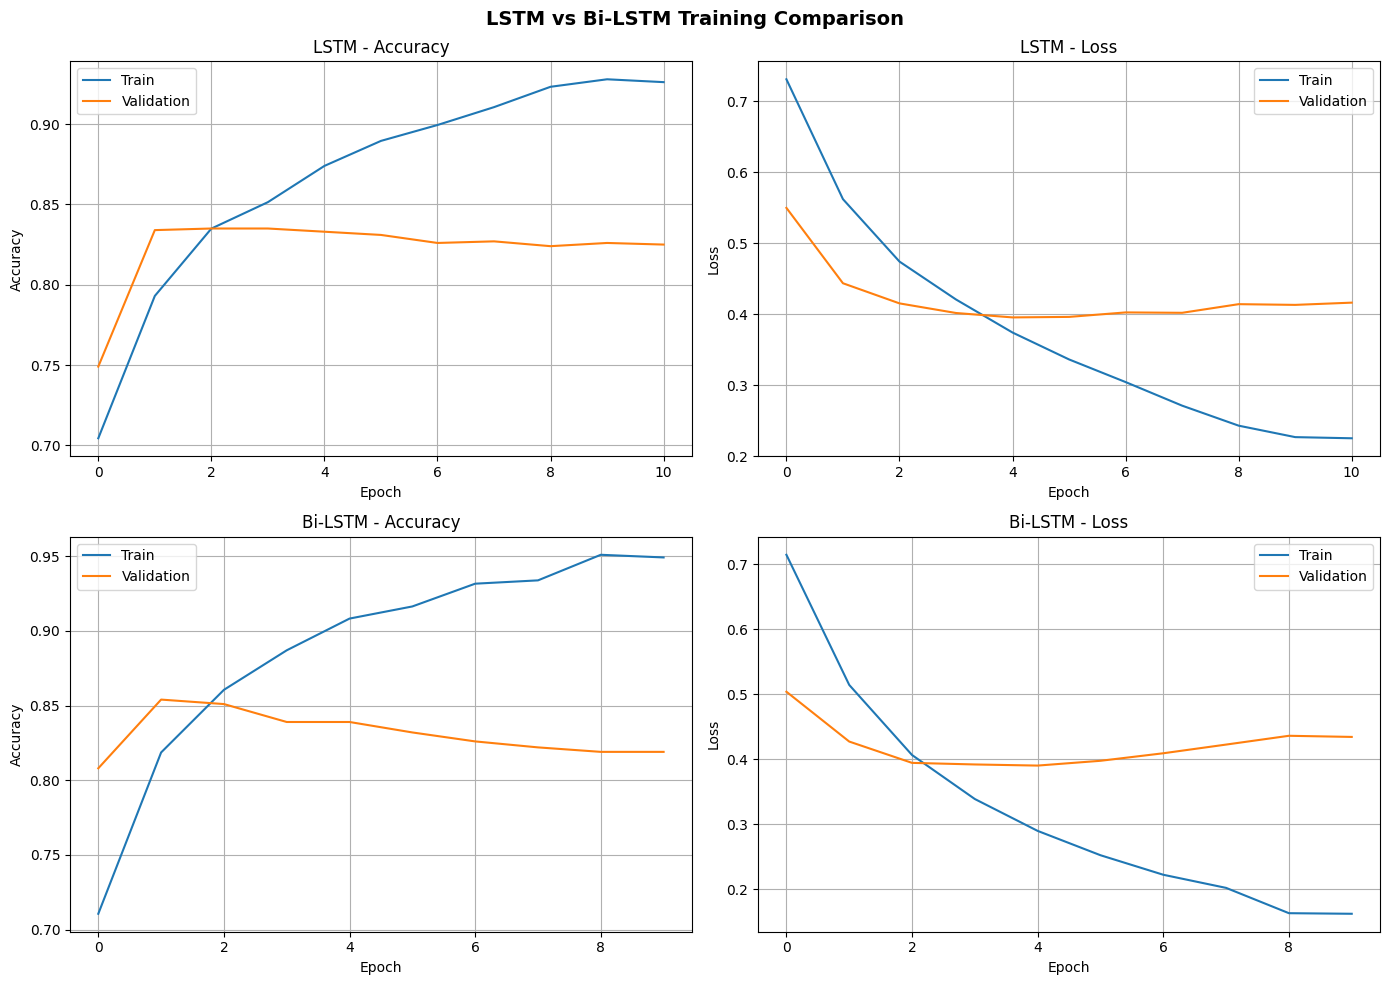

Plot saved as training_curves.png


In [133]:
# 13. Training Curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LSTM vs Bi-LSTM Training Comparison', fontsize=14, fontweight='bold')

axes[0, 0].plot(history_lstm.history['accuracy'],     label='Train')
axes[0, 0].plot(history_lstm.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('LSTM - Accuracy')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend(); axes[0, 0].grid(True)

axes[0, 1].plot(history_lstm.history['loss'],     label='Train')
axes[0, 1].plot(history_lstm.history['val_loss'], label='Validation')
axes[0, 1].set_title('LSTM - Loss')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend(); axes[0, 1].grid(True)

axes[1, 0].plot(history_bilstm.history['accuracy'],     label='Train')
axes[1, 0].plot(history_bilstm.history['val_accuracy'], label='Validation')
axes[1, 0].set_title('Bi-LSTM - Accuracy')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend(); axes[1, 0].grid(True)

axes[1, 1].plot(history_bilstm.history['loss'],     label='Train')
axes[1, 1].plot(history_bilstm.history['val_loss'], label='Validation')
axes[1, 1].set_title('Bi-LSTM - Loss')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend(); axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as training_curves.png')

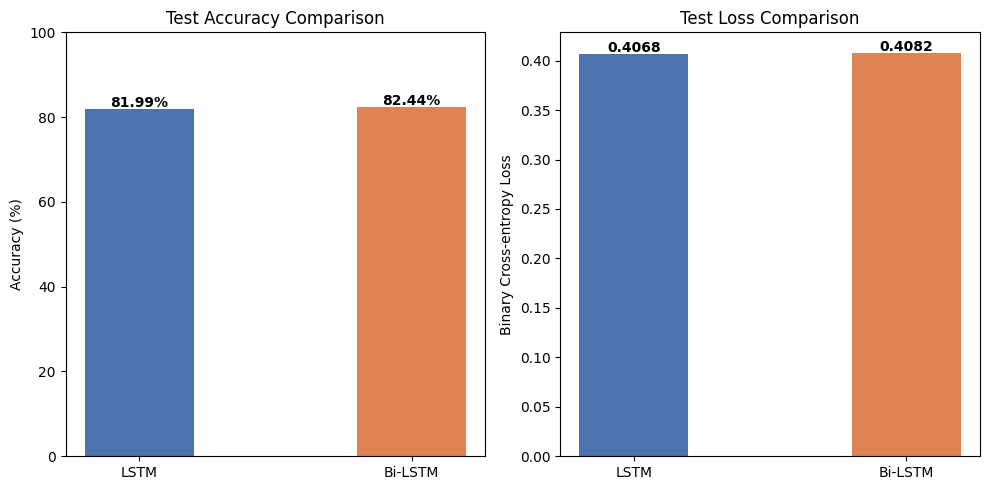

Bar chart saved as accuracy_loss_bar.png


In [134]:
# 14. Bar Chart - Accuracy & Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
models = ['LSTM', 'Bi-LSTM']
colors = ['#4C72B0', '#DD8452']

ax1.bar(models, [lstm_acc*100, bilstm_acc*100], color=colors, width=0.4)
ax1.set_title('Test Accuracy Comparison')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 100)
for i, v in enumerate([lstm_acc*100, bilstm_acc*100]):
    ax1.text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')

ax2.bar(models, [lstm_loss, bilstm_loss], color=colors, width=0.4)
ax2.set_title('Test Loss Comparison')
ax2.set_ylabel('Binary Cross-entropy Loss')
for i, v in enumerate([lstm_loss, bilstm_loss]):
    ax2.text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('accuracy_loss_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bar chart saved as accuracy_loss_bar.png')

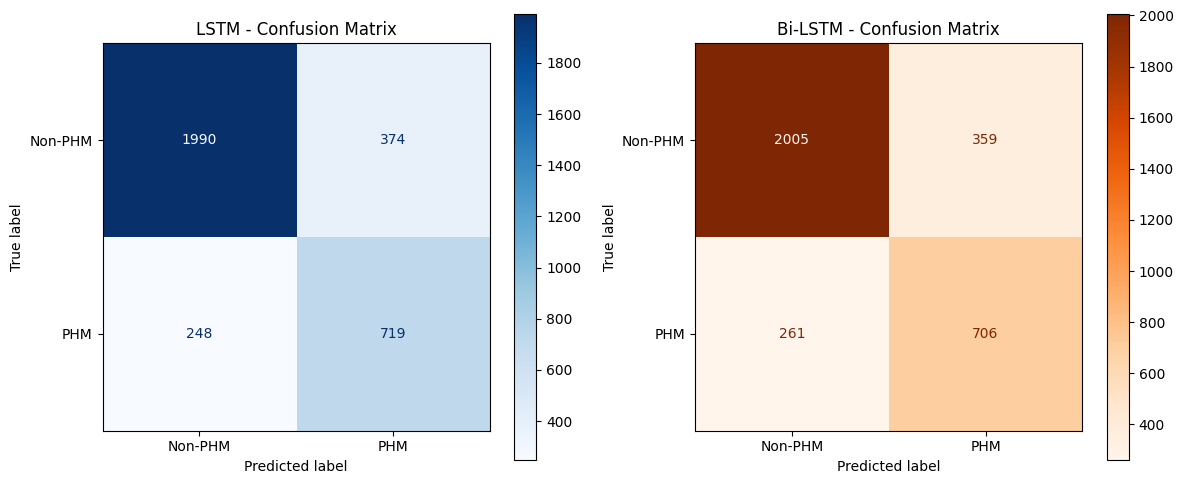

Confusion matrix saved as confusion_matrices.png


In [135]:
# 15. Confusion Matrices
from sklearn.metrics import ConfusionMatrixDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
class_names = ['Non-PHM', 'PHM']

ConfusionMatrixDisplay.from_predictions(
    y_test, lstm_pred, display_labels=class_names,
    cmap='Blues', ax=ax1
)
ax1.set_title('LSTM - Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(
    y_test, bilstm_pred, display_labels=class_names,
    cmap='Oranges', ax=ax2
)
ax2.set_title('Bi-LSTM - Confusion Matrix')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved as confusion_matrices.png')